In [1]:
import numpy as np
from skimage import io
from matplotlib import pyplot as plt
from deepcell.datasets import multiplex_tissue
from deepcell.utils.plot_utils import create_rgb_image
from deepcell.utils.plot_utils import make_outline_overlay
from PIL import Image
import pandas as pd
import tifffile
import imageio
import glob
import multiprocessing as mp
import re
import os 
Image.MAX_IMAGE_PIXELS = None

2023-10-06 00:50:25.737941: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/parvaresha/miniconda3/envs/mesmer/lib/python3.10/site-packages/cv2/../../lib64:/cm/shared/easybuild/software/Python/3.10.4-GCCcore-11.3.0/lib:/cm/shared/easybuild/software/OpenSSL/1.1/lib:/cm/shared/easybuild/software/libffi/3.4.2-GCCcore-11.3.0/lib64:/cm/shared/easybuild/software/GMP/6.2.1-GCCcore-11.3.0/lib:/cm/shared/easybuild/software/XZ/5.2.5-GCCcore-11.3.0/lib:/cm/shared/easybuild/software/SQLite/3.38.3-GCCcore-11.3.0/lib:/cm/shared/easybuild/software/Tcl/8.6.12-GCCcore-11.3.0/lib:/cm/shared/easybuild/software/libreadline/8.1.2-GCCcore-11.3.0/lib:/cm/shared/easybuild/software/ncurses/6.3-GCCcore-11.3.0/lib:/cm/shared/easybuild/software/bzip2/1.0.8-GCCcore-11.3.0/lib:/cm/shared/easybuild/software/binutils/2.38-GCCcore-11.3.0/lib:/c

In [2]:
mcmicroDir = "/path/to/sample_folder942"
inOmeTiff = glob.glob(mcmicroDir+'/*.qptiff')[0]
print(inOmeTiff)
#Make sure to adjust this to nuclear or whole cell depending on what's needed
inMaskTiff = mcmicroDir + '/segmentation_nuclear_dil.tif'

/mnt/isilon/tan_lab/parvaresha/Pediatric_Glioma/pHGG_Oldridge_Samples/942/20230818_C70848_7316-942_Scan1.qptiff


In [3]:
def sumValueByMask(mask, expr, outFile = ""):
    df = pd.DataFrame({
        'values':  np.concatenate(expr),
        'indexes': np.concatenate(mask)
    })
    out = df.pivot_table(values='values', index='indexes', aggfunc=sum)
    if(outFile != ""):
        out.to_csv(outFile)
    return out

In [4]:
mask = tifffile.imread(inMaskTiff)
print(mask.shape)

(56880, 35520)


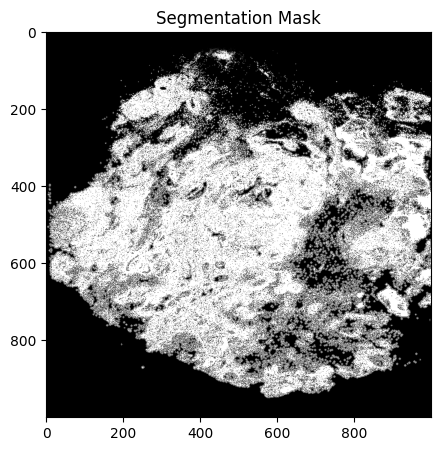

In [5]:
#Check that the tiles were merged back together correctly
maskimage = Image.open(inMaskTiff)
maskimage = maskimage.resize((1000, 1000), Image.LANCZOS)

# Plot nuclear and pan-membrane stack
fig, ax = plt.subplots(1, figsize=(5, 5))
ax.imshow(maskimage)
ax.set_title('Segmentation Mask')
plt.show()

In [6]:
#Inspect segmentation quality 
im = io.imread(mcmicroDir + '/_nuclear_panmembrane.tif')
X_train = np.transpose(im, (1,2,0))
X_train = X_train.reshape(1, X_train.shape[0], X_train.shape[1], X_train.shape[2])
rgb_images = create_rgb_image(X_train, channel_colors=['green', 'blue'])

segmentation_predictions_nuc = np.load(mcmicroDir + "segmentation_predictions_dilated_nuclear.npy")
segmentation_predictions_nuc.shape

(1, 56880, 35520, 1)

In [7]:
idx = 0
overlay_data = make_outline_overlay(rgb_data=rgb_images, predictions=segmentation_predictions_nuc)

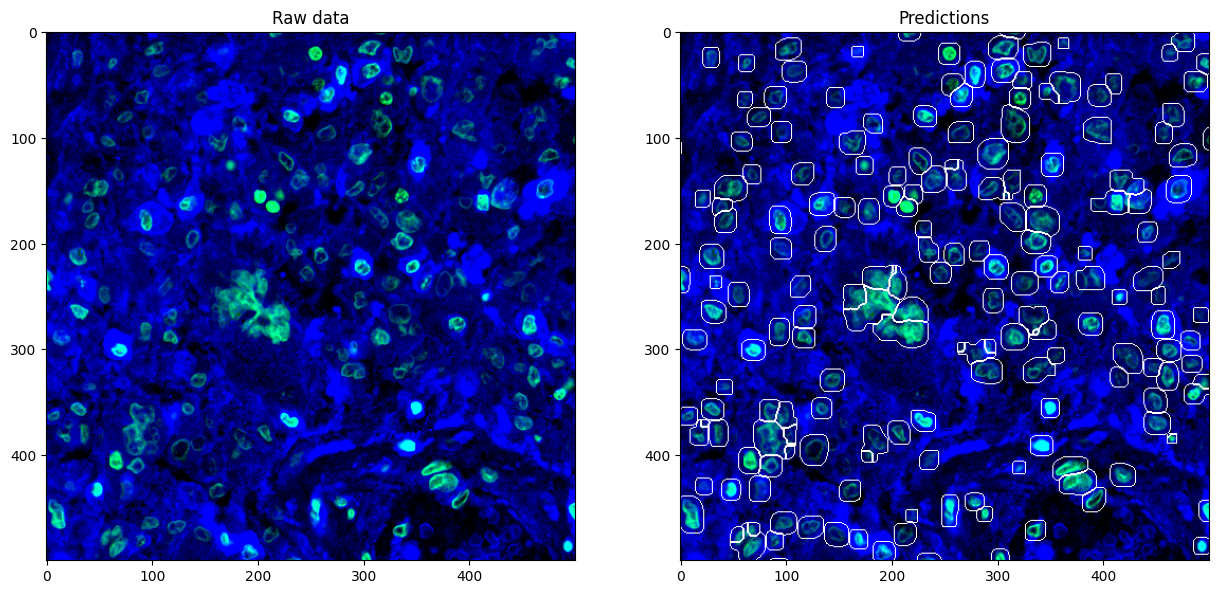

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(15, 15))
ax[0].imshow(rgb_images[idx, 10500:11000, 10500:11000])
ax[1].imshow(overlay_data[idx, 10500:11000, 10500:11000])

ax[0].set_title('Raw data')
ax[1].set_title('Predictions')
plt.show()
borders = overlay_data[0, ...]-rgb_images[idx, ...]

In [9]:
df = pd.DataFrame({
  'values': np.concatenate(np.full(mask.shape,1)),
  'indexes': np.concatenate(mask)
})

size = sumValueByMask(mask, np.full(mask.shape,1), mcmicroDir + '/mesmer/Pix4/cell_size.csv')

coordX = sumValueByMask(
    mask, 
    np.tile(
        np.array(range(0,mask.shape[1])), 
        (mask.shape[0], 1)),
    mcmicroDir + '/cell_x_coord.csv')

coordY = sumValueByMask(
    mask, 
    np.transpose(np.tile(
        np.array(range(0,mask.shape[0])), 
        (mask.shape[1], 1))),
    mcmicroDir + '/cell_y_coord.csv')   



In [10]:
im = tifffile.imread(inOmeTiff)
print(im.shape)
print(mask.shape)
print(im.max())
print(mask.max())

(57, 56880, 35520)
(56880, 35520)
255
506283


In [11]:
outFiles = [mcmicroDir + '/channel_C{:02d}.csv'.format(ii) for ii in range(im.shape[0])]

In [12]:
for ii in range(len(outFiles)):
    print(ii)
    sumValueByMask(mask, im[ii,:,:], outFiles[ii])

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56


In [13]:
# Create a super-csv from segmentation results for downstream analysis
import os
csvDir = os.path.join(mcmicroDir)
csvFileArray = sorted(glob.glob(csvDir + "/*.csv"))
print("Output Directory is " + csvDir)
df_list = []
for filename in csvFileArray:
    df = pd.read_csv(filename, header=0)
    df = df.rename(columns={"values": str(filename)}) # changes "values" to the filename
    df_list.append(df)
col_names = [str(i) for i in csvFileArray]
dfs = [df.set_index('indexes') for df in df_list]
frame = pd.concat(dfs, axis=1)
print(np.shape(frame)) # to confirm that the data-frame has written the correct number of columns
frame.to_csv(os.path.join(csvDir + '/combined_markers.csv'), index=True)

Output Directory is /mnt/isilon/tan_lab/parvaresha/Pediatric_Glioma/pHGG_Oldridge_Samples/942/mesmer/Pix4
(506284, 60)
